# Plotting in Python

Some interactive figures won't work without a Jupyter kernel running.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from plotnine import *
import plotly.express as px
import datashader as ds
import datashader.transfer_functions as tf
import colorcet as cc
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Setup
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
print("Environment Ready.")

Environment Ready.


# Dataset

In [3]:
n_samples = 300
df = pd.DataFrame({
    'Sample_ID': [f'S_{i:03d}' for i in range(n_samples)],
    'Group': np.random.choice(['Control', 'Treatment_A', 'Treatment_B'], n_samples),
    'Age': np.random.randint(20, 80, n_samples),
    'Gene_X_Log2FC': np.random.normal(0, 1, n_samples),
    'Gene_Y_Log2FC': np.random.normal(0, 1, n_samples),
    'Pathway_Activity': np.random.exponential(1, n_samples)
})

df.loc[df['Group'] == 'Treatment_A', 'Gene_X_Log2FC'] += 2.5
df.loc[df['Group'] == 'Treatment_B', 'Gene_Y_Log2FC'] -= 1.5

# Matplotlib

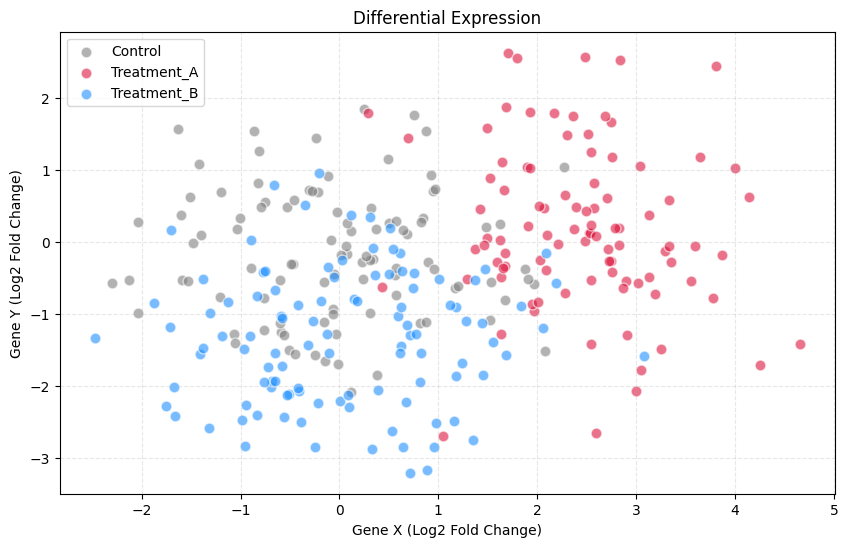

In [4]:
fig, ax = plt.subplots()
colors = {'Control': 'gray', 'Treatment_A': 'crimson', 'Treatment_B': 'dodgerblue'}

for group, color in colors.items():
    subset = df[df['Group'] == group]
    ax.scatter(subset['Gene_X_Log2FC'], subset['Gene_Y_Log2FC'], 
               c=color, label=group, alpha=0.6, edgecolors='white', s=60)

ax.set_title('Differential Expression')
ax.set_xlabel('Gene X (Log2 Fold Change)')
ax.set_ylabel('Gene Y (Log2 Fold Change)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Seaborn

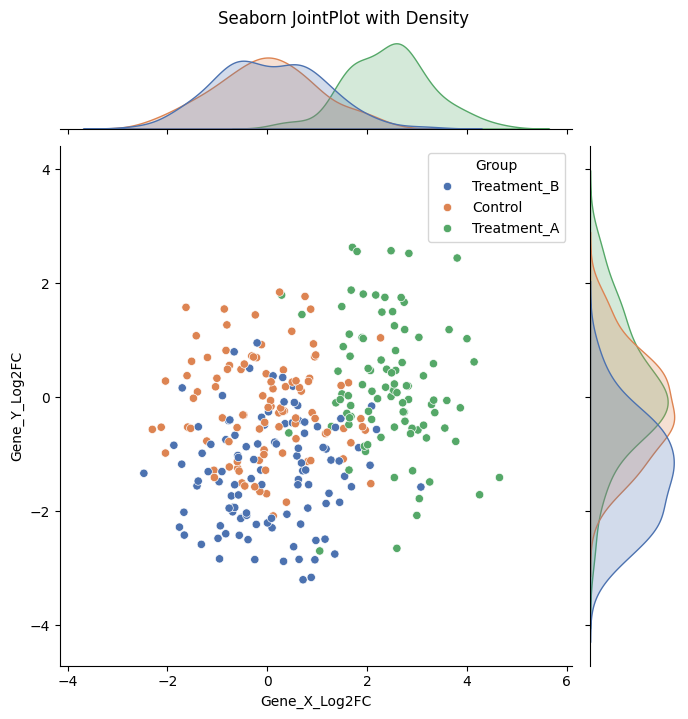

In [5]:
# Jointplot: Scatter + Density histograms
g = sns.jointplot(data=df, x='Gene_X_Log2FC', y='Gene_Y_Log2FC', hue='Group', 
                  kind='scatter', palette='deep', height=7)
g.fig.suptitle('Seaborn JointPlot with Density', y=1.02)
plt.show()

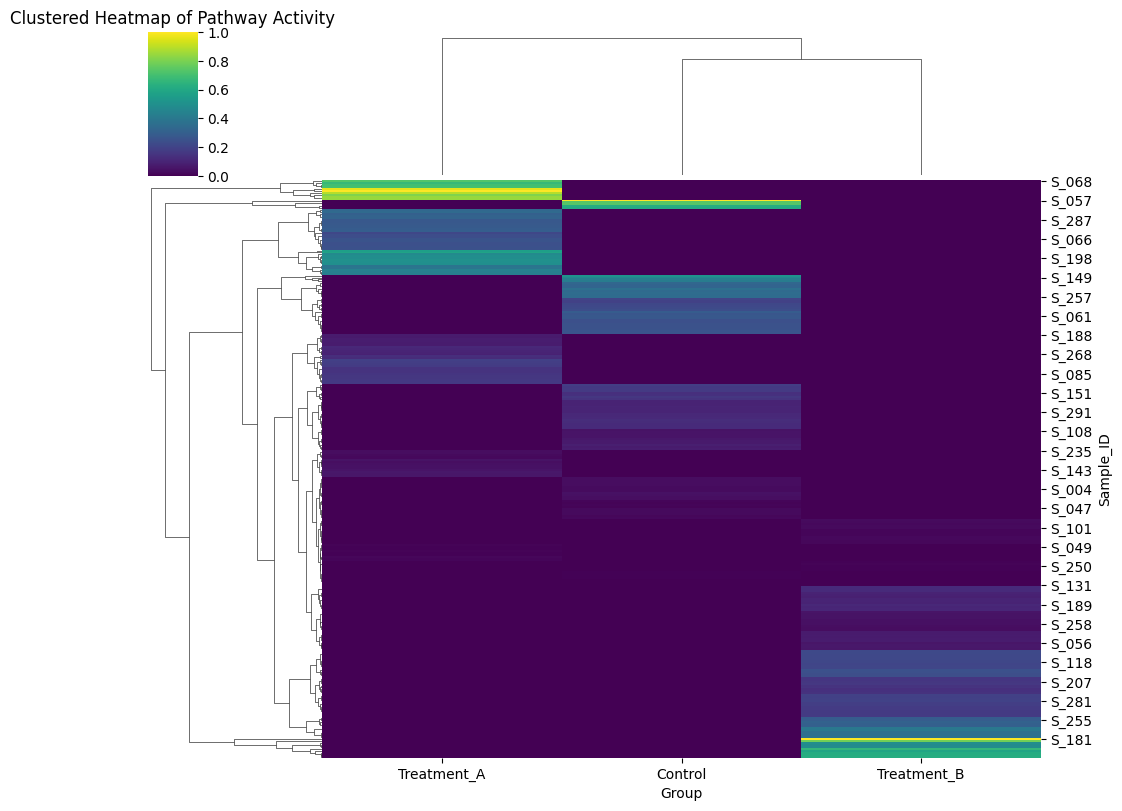

In [6]:
# Seaborn Clustered Heatmap
pivot_table = df.pivot_table(index='Sample_ID', columns='Group', values='Pathway_Activity', fill_value=0)
sns.clustermap(pivot_table, cmap='viridis', standard_scale=1, figsize=(10, 8))
plt.title('Clustered Heatmap of Pathway Activity')
plt.show()

In [ ]:
# Create sample dataset
np.random.seed(42)
samples = [f'Sample_{i}' for i in range(1, 21)]
groups = ['Control', 'Treatment_A', 'Treatment_B']
pathways = ['MAPK', 'PI3K', 'Wnt', 'Notch', 'Hedgehog']

sample_to_group = {sample: np.random.choice(groups) for sample in samples}

# Generate sample data
data = []
for sample in samples:
    for pathway in pathways:
        # Use the pre-assigned group
        group = sample_to_group[sample]
        
        # Add some slight pattern logic so clustering is visible
        base = 5
        if group == 'Control': base = 3
        elif group == 'Treatment_A' and pathway in ['MAPK', 'PI3K']: base = 8
        elif group == 'Treatment_B' and pathway in ['Wnt', 'Notch']: base = 8
        
        activity = np.random.normal(base, 1.5) # Normal dist feels more natural than uniform
        activity = max(0, activity) # Ensure no negative values
        
        data.append({
            'Sample_ID': sample,
            'Group': group,
            'Pathway': pathway,
            'Pathway_Activity': activity
        })

df_seaborn = pd.DataFrame(data)

# Create pivot table
pivot_table = df_seaborn.pivot_table(
    index='Sample_ID', 
    columns='Pathway', 
    values='Pathway_Activity', 
    fill_value=0
)

# Create row colors for samples (annotation)
sample_groups = df_seaborn.groupby('Sample_ID')['Group'].first()
group_colors = {'Control': '#1f77b4', 'Treatment_A': '#ff7f0e', 'Treatment_B': '#2ca02c'}
row_colors = sample_groups.map(group_colors)

# Create column colors for pathways (annotation)
pathway_categories = {
    'MAPK': 'Signaling',
    'PI3K': 'Signaling',
    'Wnt': 'Development',
    'Notch': 'Development',
    'Hedgehog': 'Development'
}

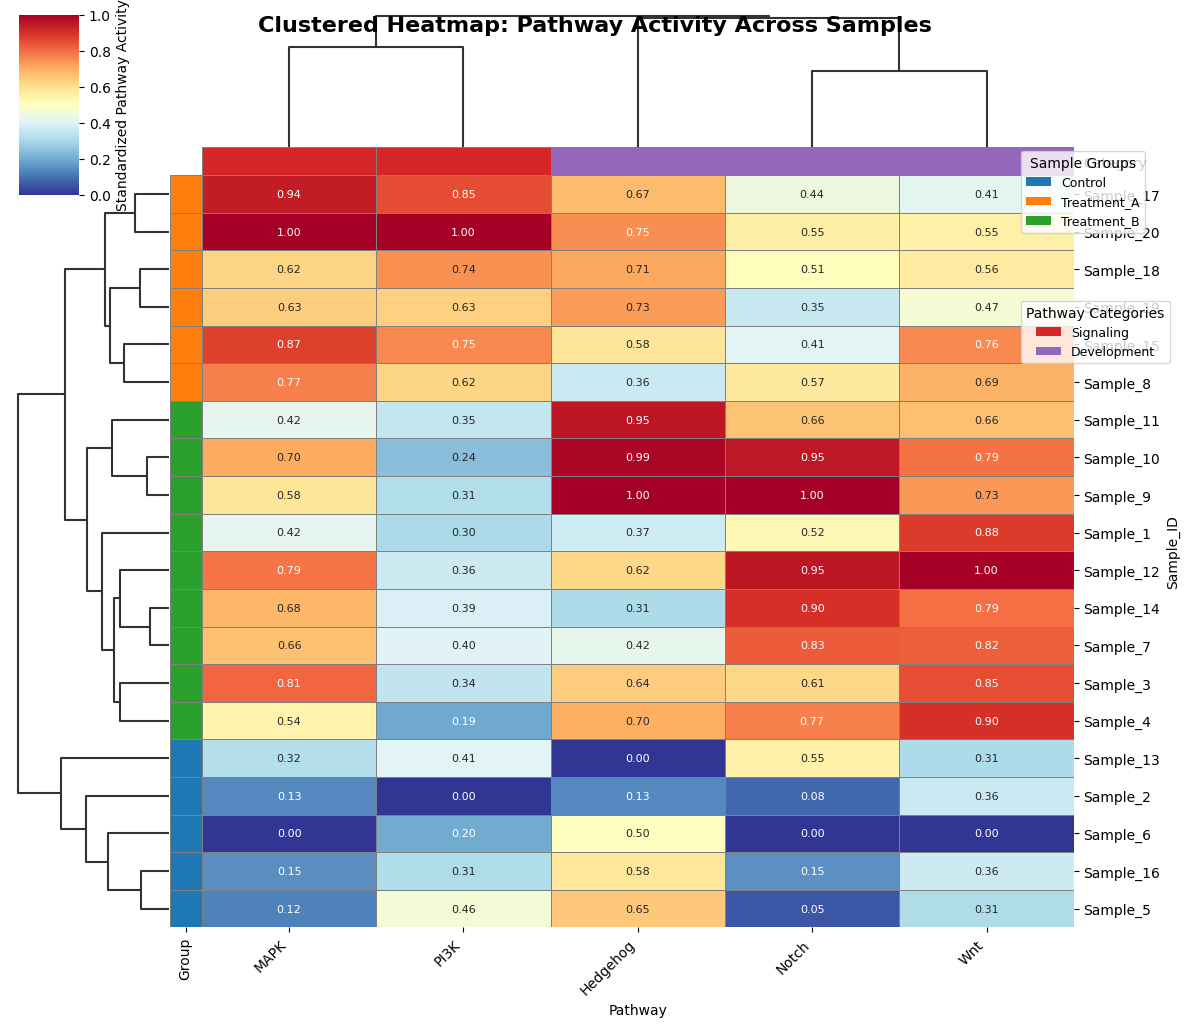

In [8]:
pathway_colors = {'Signaling': '#d62728', 'Development': '#9467bd'}

col_colors = pd.Series(
    [pathway_colors[pathway_categories[p]] for p in pivot_table.columns],
    index=pivot_table.columns, 
    name='Category'
)

# Create highly customized clustered heatmap
g = sns.clustermap(
    pivot_table,
    cmap='RdYlBu_r', 
    standard_scale=1, 
    figsize=(12, 10),
    
    # Clustering parameters
    method='average', 
    metric='euclidean',
    
    # Annotations
    row_colors=row_colors,
    col_colors=col_colors,
    
    # Dendrogram customization
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=0.15,
    colors_ratio=0.03,
    
    # Cell annotations
    annot=True, 
    fmt='.2f', 
    annot_kws={'size': 8},
    
    # Colorbar customization
    cbar_kws={
        'label': 'Standardized Pathway Activity',
        'orientation': 'vertical',
    },
    
    # Cell appearance
    linewidths=0.5,
    linecolor='gray',
    
    # Tree appearance
    tree_kws={'linewidths': 1.5}
)

g.ax_cbar.tick_params(labelsize=10)

# Add title
g.fig.suptitle('Clustered Heatmap: Pathway Activity Across Samples', 
               fontsize=16, fontweight='bold', y=0.98)

# Rotate labels for better readability
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)

# Create custom legends for annotations
# Legend for sample groups
group_legend = [Patch(facecolor=color, label=group) 
                for group, color in group_colors.items()]
legend1 = g.fig.legend(handles=group_legend, title='Sample Groups',
                       loc='upper left', bbox_to_anchor=(0.85, 0.85),
                       frameon=True, fontsize=9)

# Legend for pathway categories
pathway_legend = [Patch(facecolor=color, label=category) 
                  for category, color in pathway_colors.items()]
legend2 = g.fig.legend(handles=pathway_legend, title='Pathway Categories',
                       loc='upper left', bbox_to_anchor=(0.85, 0.70),
                       frameon=True, fontsize=9)

plt.show()

# Plotnine

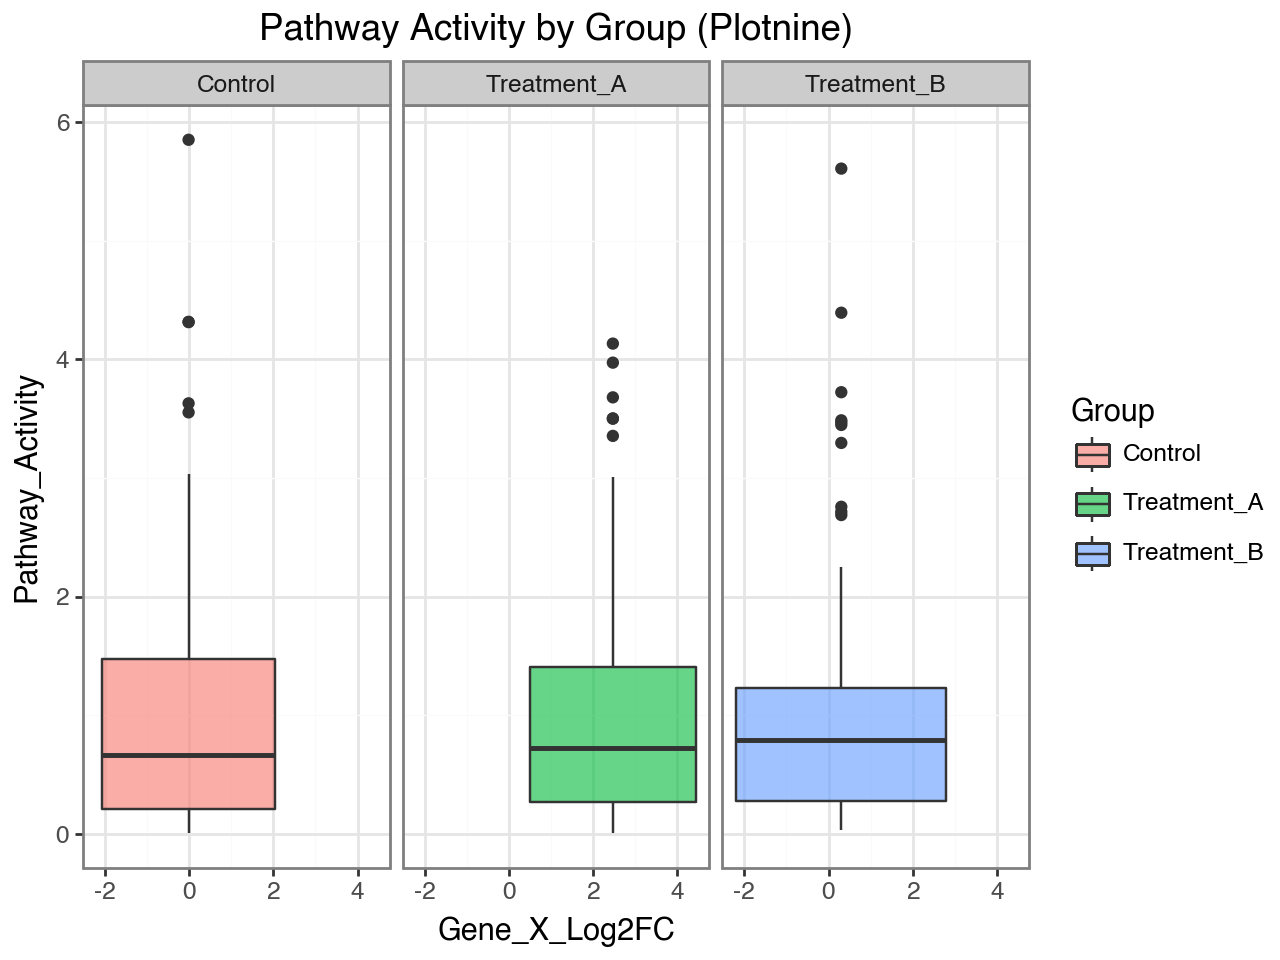

In [9]:
p = (
    ggplot(df, aes(x='Gene_X_Log2FC', y='Pathway_Activity', fill='Group'))
    + geom_boxplot(alpha=0.6)
    + facet_wrap('~Group')
    + theme_bw()
    + labs(title="Pathway Activity by Group (Plotnine)")
)
display(p)

1. Volcano Plot with Significance Regions


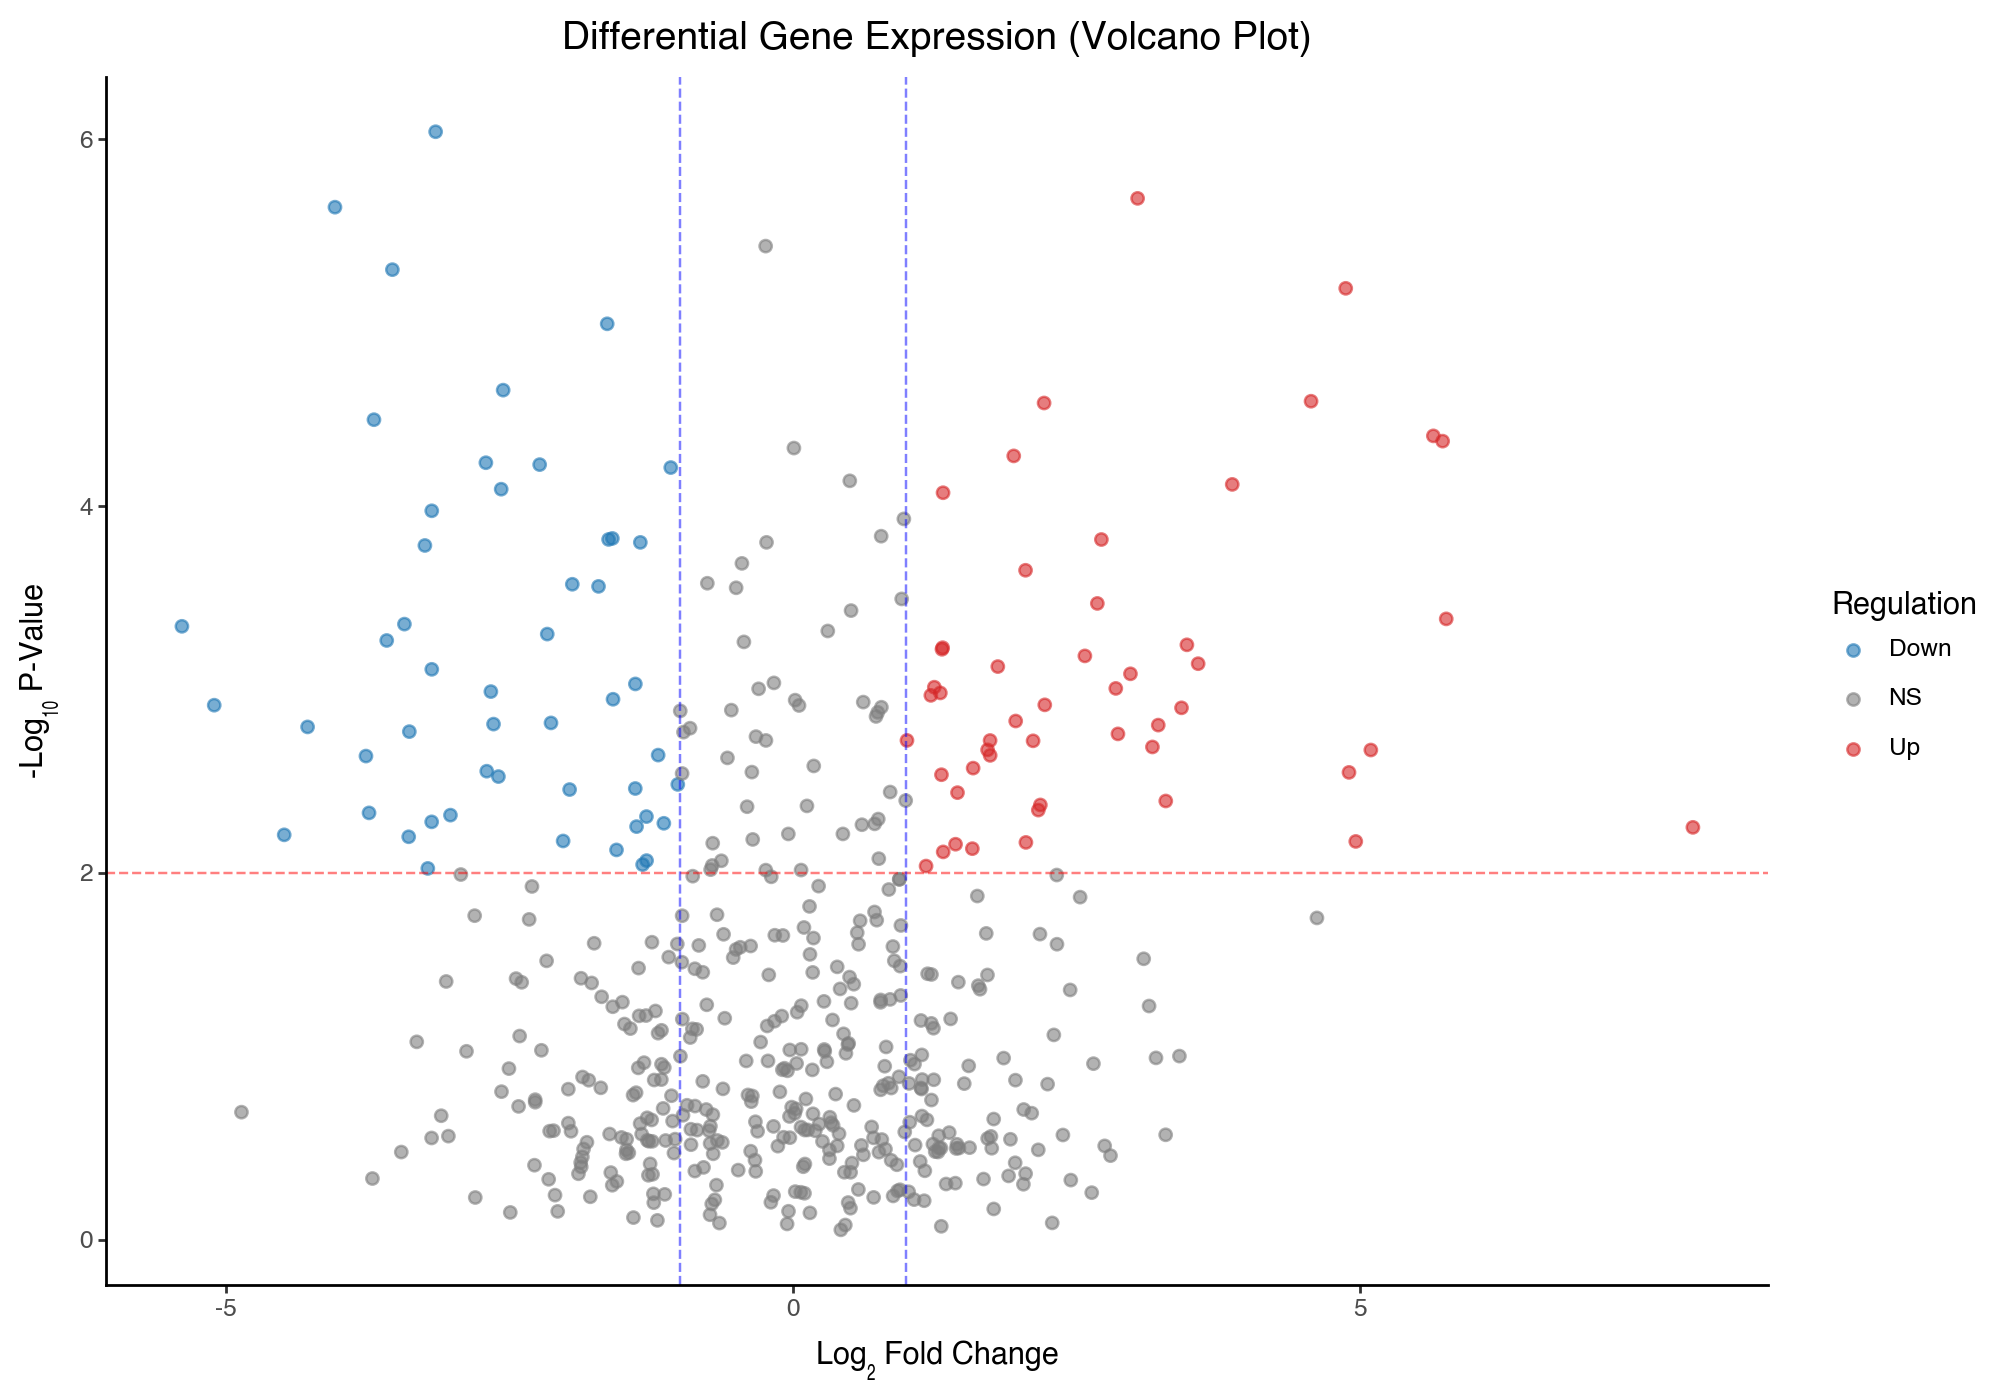

In [10]:
print("1. Volcano Plot with Significance Regions")

n_genes = 500
volcano_df = pd.DataFrame({
    'Gene': [f'Gene_{i:03d}' for i in range(n_genes)],
    'Log2FC': np.random.normal(0, 1.5, n_genes),
    'PValue': np.random.beta(0.5, 2, n_genes)
})

# Add some significantly DE genes
sig_indices = np.random.choice(n_genes, 80, replace=False)
volcano_df.loc[sig_indices, 'Log2FC'] += np.random.choice([-3, 3], 80) * np.random.uniform(0.5, 1, 80)
volcano_df.loc[sig_indices, 'PValue'] *= 0.01

volcano_df['NegLog10P'] = -np.log10(volcano_df['PValue'] + 1e-10)
volcano_df['Regulation'] = 'NS'
volcano_df.loc[(volcano_df['Log2FC'] > 1) & (volcano_df['NegLog10P'] > 2), 'Regulation'] = 'Up'
volcano_df.loc[(volcano_df['Log2FC'] < -1) & (volcano_df['NegLog10P'] > 2), 'Regulation'] = 'Down'

volcano_plot = (
    ggplot(volcano_df, aes(x='Log2FC', y='NegLog10P', color='Regulation'))
    + geom_point(alpha=0.6, size=2)
    + geom_hline(yintercept=2, linetype='dashed', color='red', alpha=0.5)
    + geom_vline(xintercept=-1, linetype='dashed', color='blue', alpha=0.5)
    + geom_vline(xintercept=1, linetype='dashed', color='blue', alpha=0.5)
    + scale_color_manual(values={'Up': '#d62728', 'Down': '#1f77b4', 'NS': '#7f7f7f'})
    + labs(title='Differential Gene Expression (Volcano Plot)',
           x='Log₂ Fold Change',
           y='-Log₁₀ P-Value')
    + theme_classic()
    + theme(figure_size=(10, 7),
            plot_title=element_text(size=14, weight='bold'),
            legend_position='right')
)
display(volcano_plot)

## Some functions are not implemented yet!

In [11]:
# print("\n2. Ridgeline/Joy Plot with Facets")

# time_course = pd.DataFrame({
#     'Time': np.repeat(['0h', '6h', '12h', '24h', '48h'], 200),
#     'Expression': np.concatenate([
#         np.random.normal(5, 1, 200),
#         np.random.normal(6, 1.2, 200),
#         np.random.normal(7.5, 1.5, 200),
#         np.random.normal(6.5, 1.3, 200),
#         np.random.normal(5.5, 1, 200)
#     ]),
#     'CellType': np.tile(np.repeat(['Neuron', 'Astrocyte'], 100), 5)
# })

# ridgeline = (
#     ggplot(time_course, aes(x='Expression', y='Time', fill='Time'))
#     + geom_density_ridges(alpha=0.7, scale=0.9)
#     + facet_wrap('~CellType', ncol=2)
#     + scale_fill_brewer(type='seq', palette='YlOrRd')
#     + labs(title='Gene Expression Over Time (Ridgeline Plot)',
#            x='Expression Level (TPM)',
#            y='Time Point')
#     + theme_minimal()
#     + theme(figure_size=(12, 6),
#             strip_background=element_rect(fill='lightgray'),
#             strip_text=element_text(weight='bold'),
#             legend_position='none')
# )
# print(ridgeline)


3. Violin + Sina Plot (Individual Points Visible)


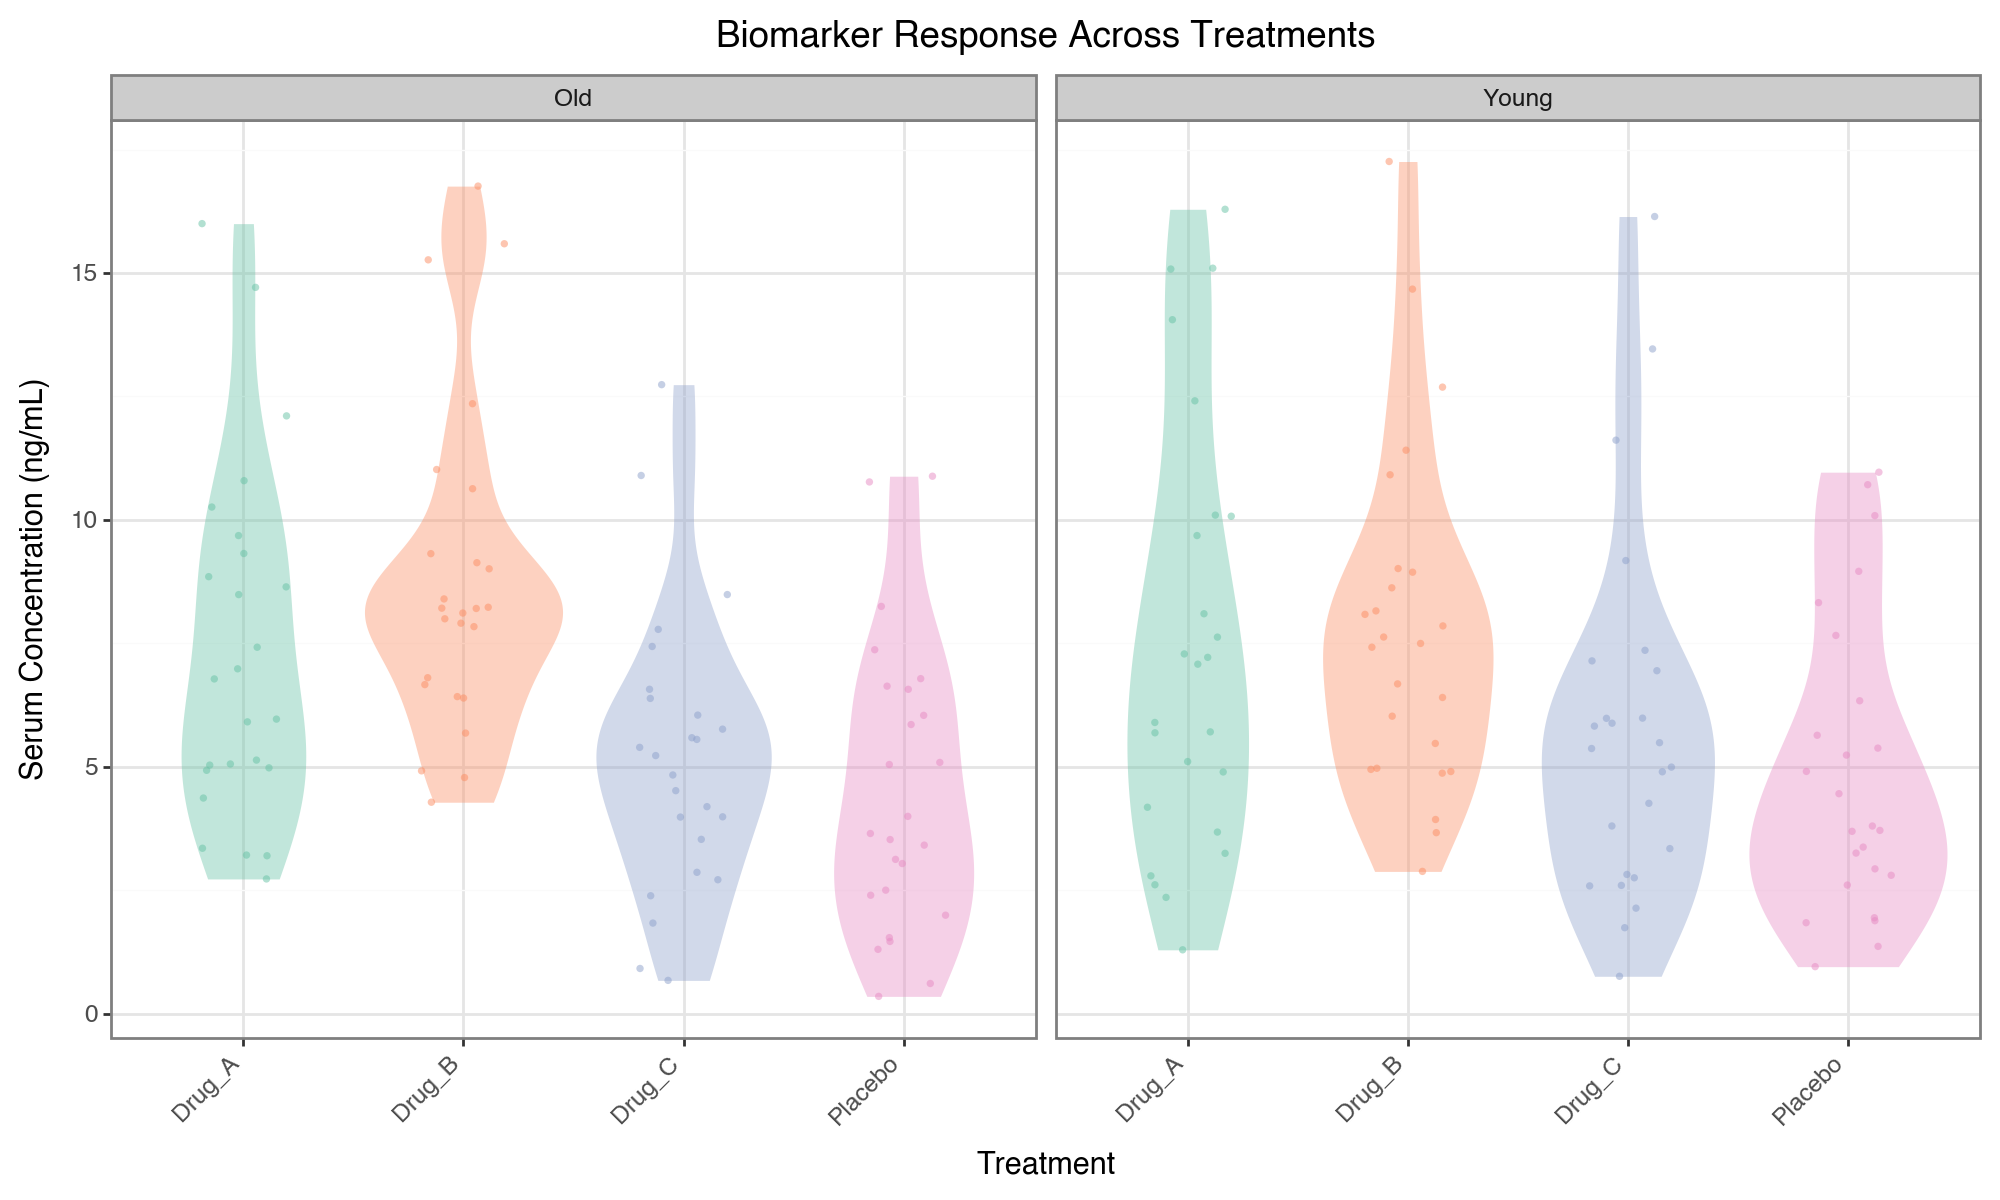

In [12]:
print("\n3. Violin + Sina Plot (Individual Points Visible)")

clinical_df = pd.DataFrame({
    'Treatment': np.repeat(['Placebo', 'Drug_A', 'Drug_B', 'Drug_C'], 50),
    'Biomarker': np.concatenate([
        np.random.gamma(2, 2, 50),
        np.random.gamma(3, 2.5, 50),
        np.random.gamma(4, 2, 50),
        np.random.gamma(2.5, 3, 50)
    ]),
    'Cohort': np.tile(['Young', 'Old'], 100)
})

violin_sina = (
    ggplot(clinical_df, aes(x='Treatment', y='Biomarker', fill='Treatment'))
    + geom_violin(alpha=0.4, color='none')
    + geom_jitter(width=0.2, alpha=0.5, size=1.5, stroke=0)
    + facet_wrap('~Cohort')
    + scale_fill_brewer(type='qual', palette='Set2')
    + labs(title='Biomarker Response Across Treatments',
           y='Serum Concentration (ng/mL)')
    + theme_bw()
    + theme(figure_size=(10, 6),
            axis_text_x=element_text(rotation=45, hjust=1),
            legend_position='none')
)
display(violin_sina)


4. Correlation Heatmap (Tile Plot)


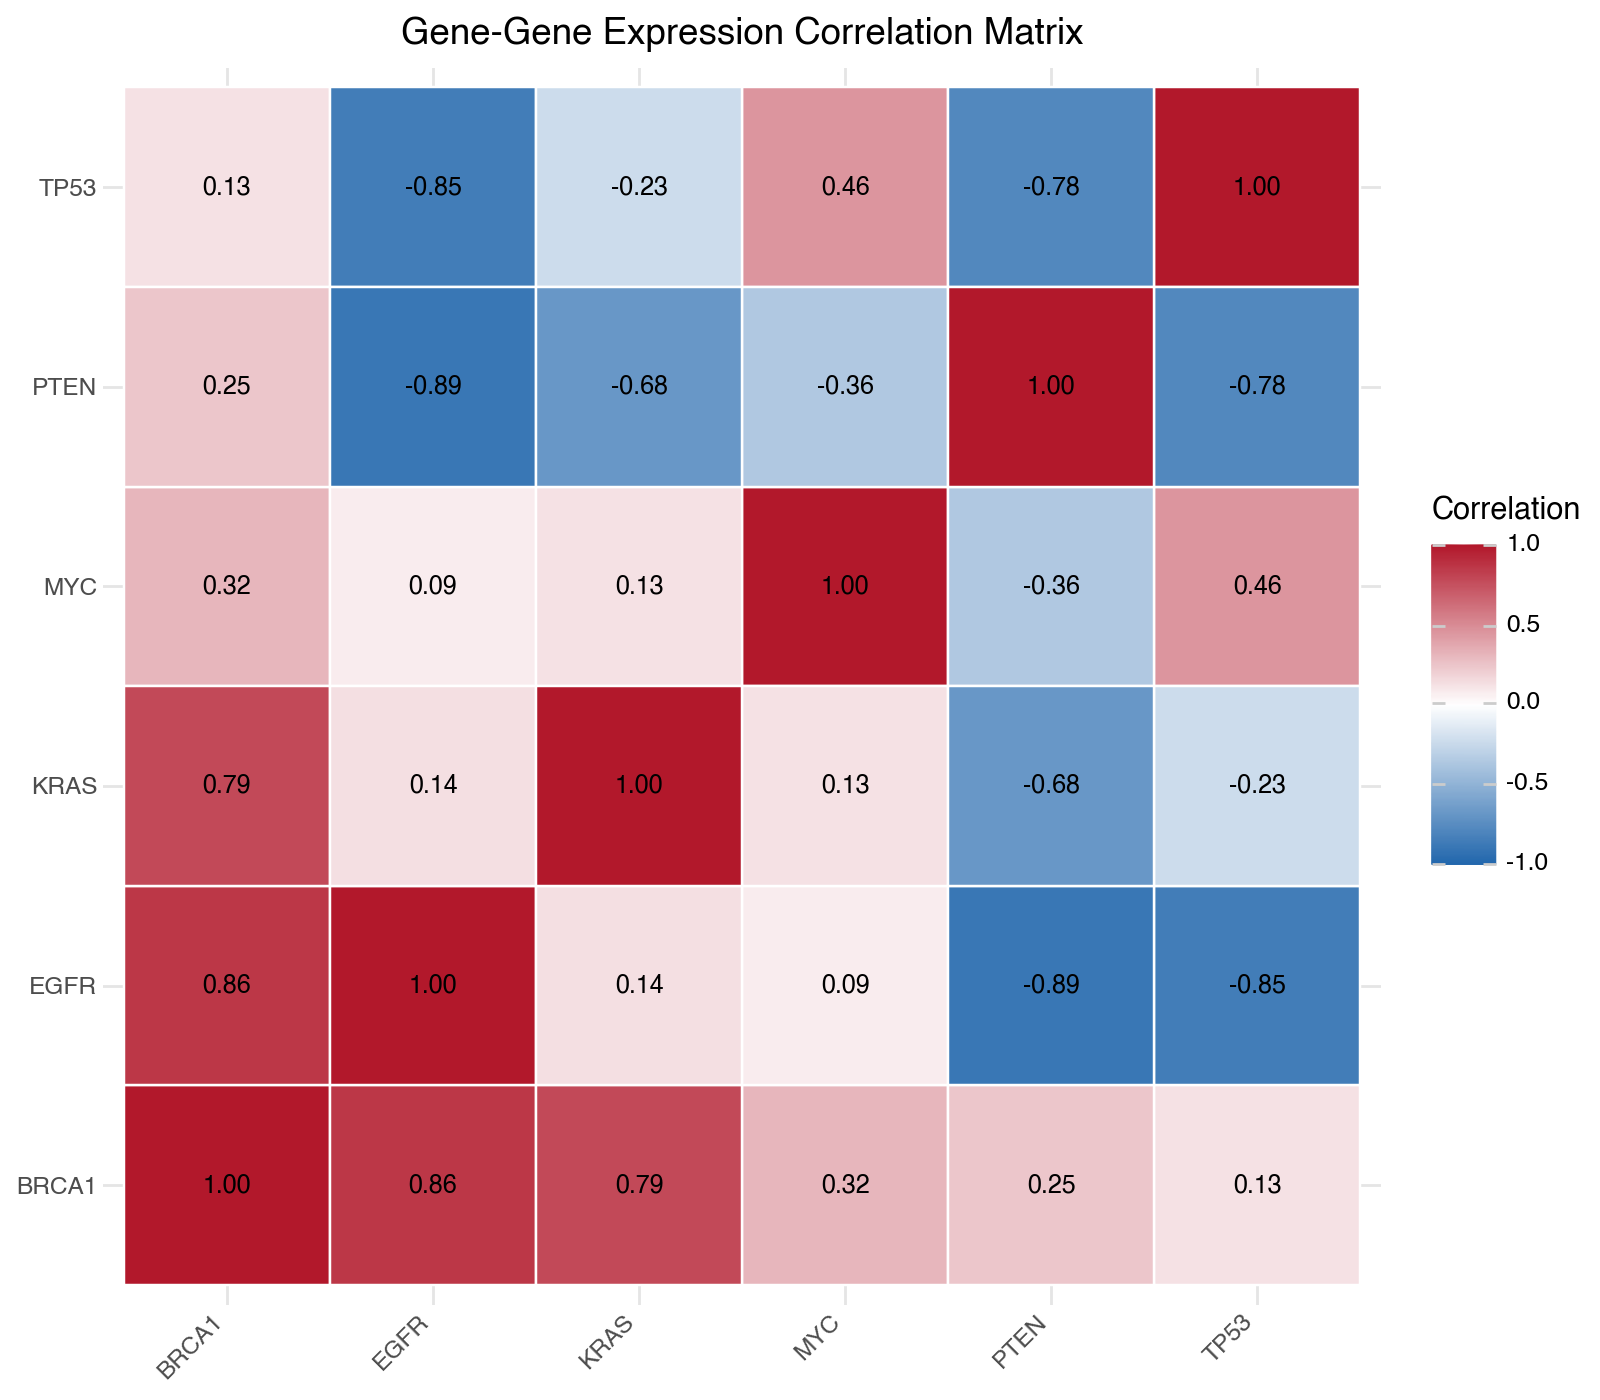

In [13]:
print("\n4. Correlation Heatmap (Tile Plot)")

# Generate correlation matrix
genes = ['BRCA1', 'TP53', 'EGFR', 'MYC', 'KRAS', 'PTEN']
n = len(genes)
corr_matrix = np.random.uniform(-1, 1, (n, n))
corr_matrix = (corr_matrix + corr_matrix.T) / 2  # Make symmetric
np.fill_diagonal(corr_matrix, 1)

corr_df = pd.DataFrame(corr_matrix, columns=genes, index=genes)
corr_long = corr_df.reset_index().melt(id_vars='index')
corr_long.columns = ['Gene1', 'Gene2', 'Correlation']

heatmap = (
    ggplot(corr_long, aes(x='Gene1', y='Gene2', fill='Correlation'))
    + geom_tile(color='white', size=0.5)
    + geom_text(aes(label='Correlation'), format_string='{:.2f}', size=9)
    + scale_fill_gradient2(low='#2166ac', mid='white', high='#b2182b', 
                           midpoint=0, limits=[-1, 1])
    + labs(title='Gene-Gene Expression Correlation Matrix',
           x='', y='')
    + theme_minimal()
    + theme(figure_size=(8, 7),
            axis_text_x=element_text(rotation=45, hjust=1),
            plot_title=element_text(weight='bold'))
)
display(heatmap)


5. Treatment Response Flow (Alluvial-style)


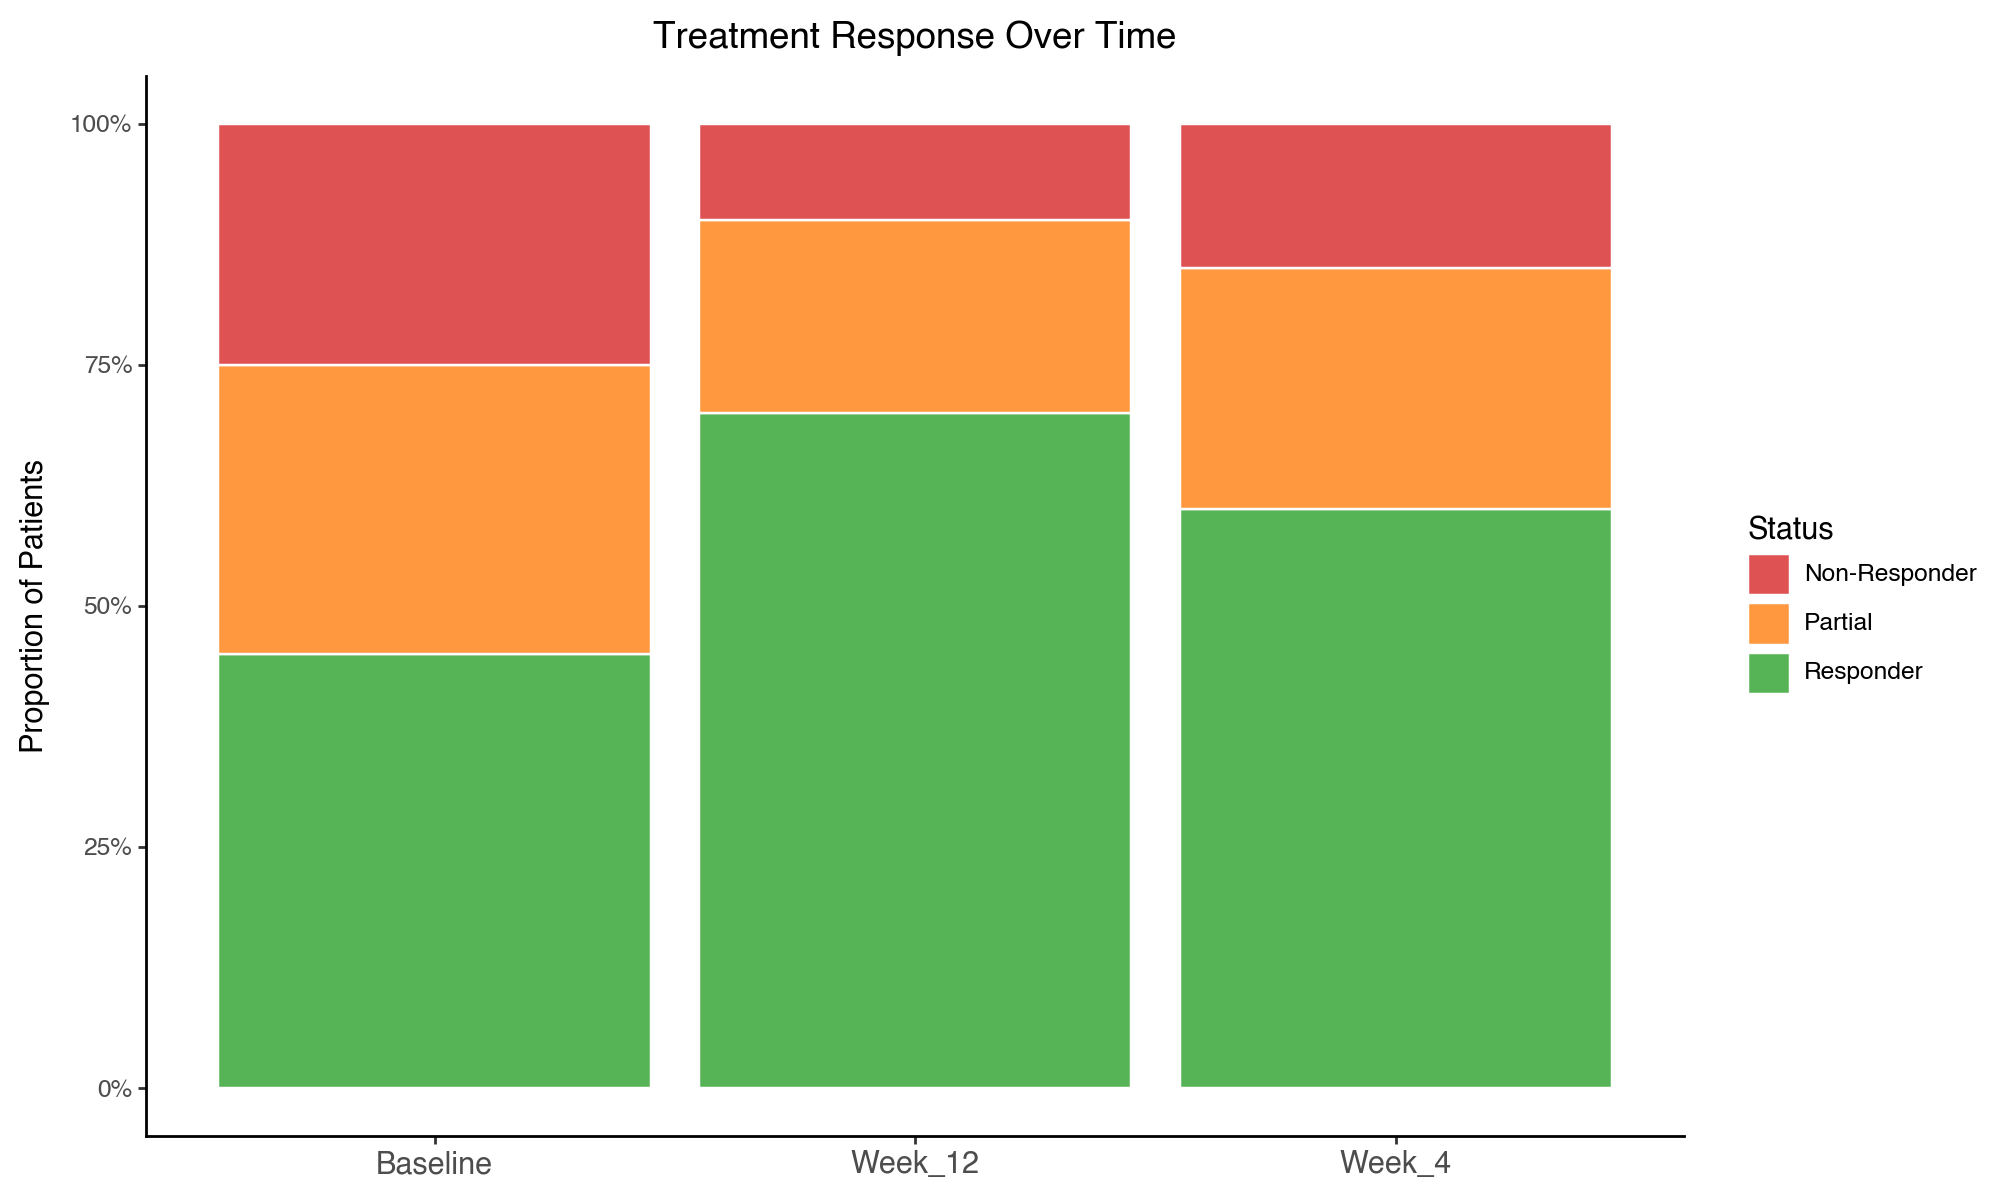

In [14]:
print("\n5. Treatment Response Flow (Alluvial-style)")

flow_df = pd.DataFrame({
    'Stage': ['Baseline', 'Baseline', 'Baseline', 
              'Week_4', 'Week_4', 'Week_4',
              'Week_12', 'Week_12', 'Week_12'],
    'Status': ['Responder', 'Partial', 'Non-Responder'] * 3,
    'Count': [45, 30, 25, 60, 25, 15, 70, 20, 10],
    'Group': ['A', 'B', 'C'] * 3
})

flow_plot = (
    ggplot(flow_df, aes(x='Stage', y='Count', fill='Status', group='Status'))
    + geom_col(position='fill', alpha=0.8, color='white', size=0.5)
    + scale_y_continuous(labels=lambda l: [f'{int(v*100)}%' for v in l])
    + scale_fill_manual(values={'Responder': '#2ca02c', 
                                'Partial': '#ff7f0e', 
                                'Non-Responder': '#d62728'})
    + labs(title='Treatment Response Over Time',
           y='Proportion of Patients',
           x='')
    + theme_classic()
    + theme(figure_size=(10, 6),
            legend_position='right',
            axis_text_x=element_text(size=11))
)
display(flow_plot)


6. 2D Density Contour (Flow Cytometry Style)


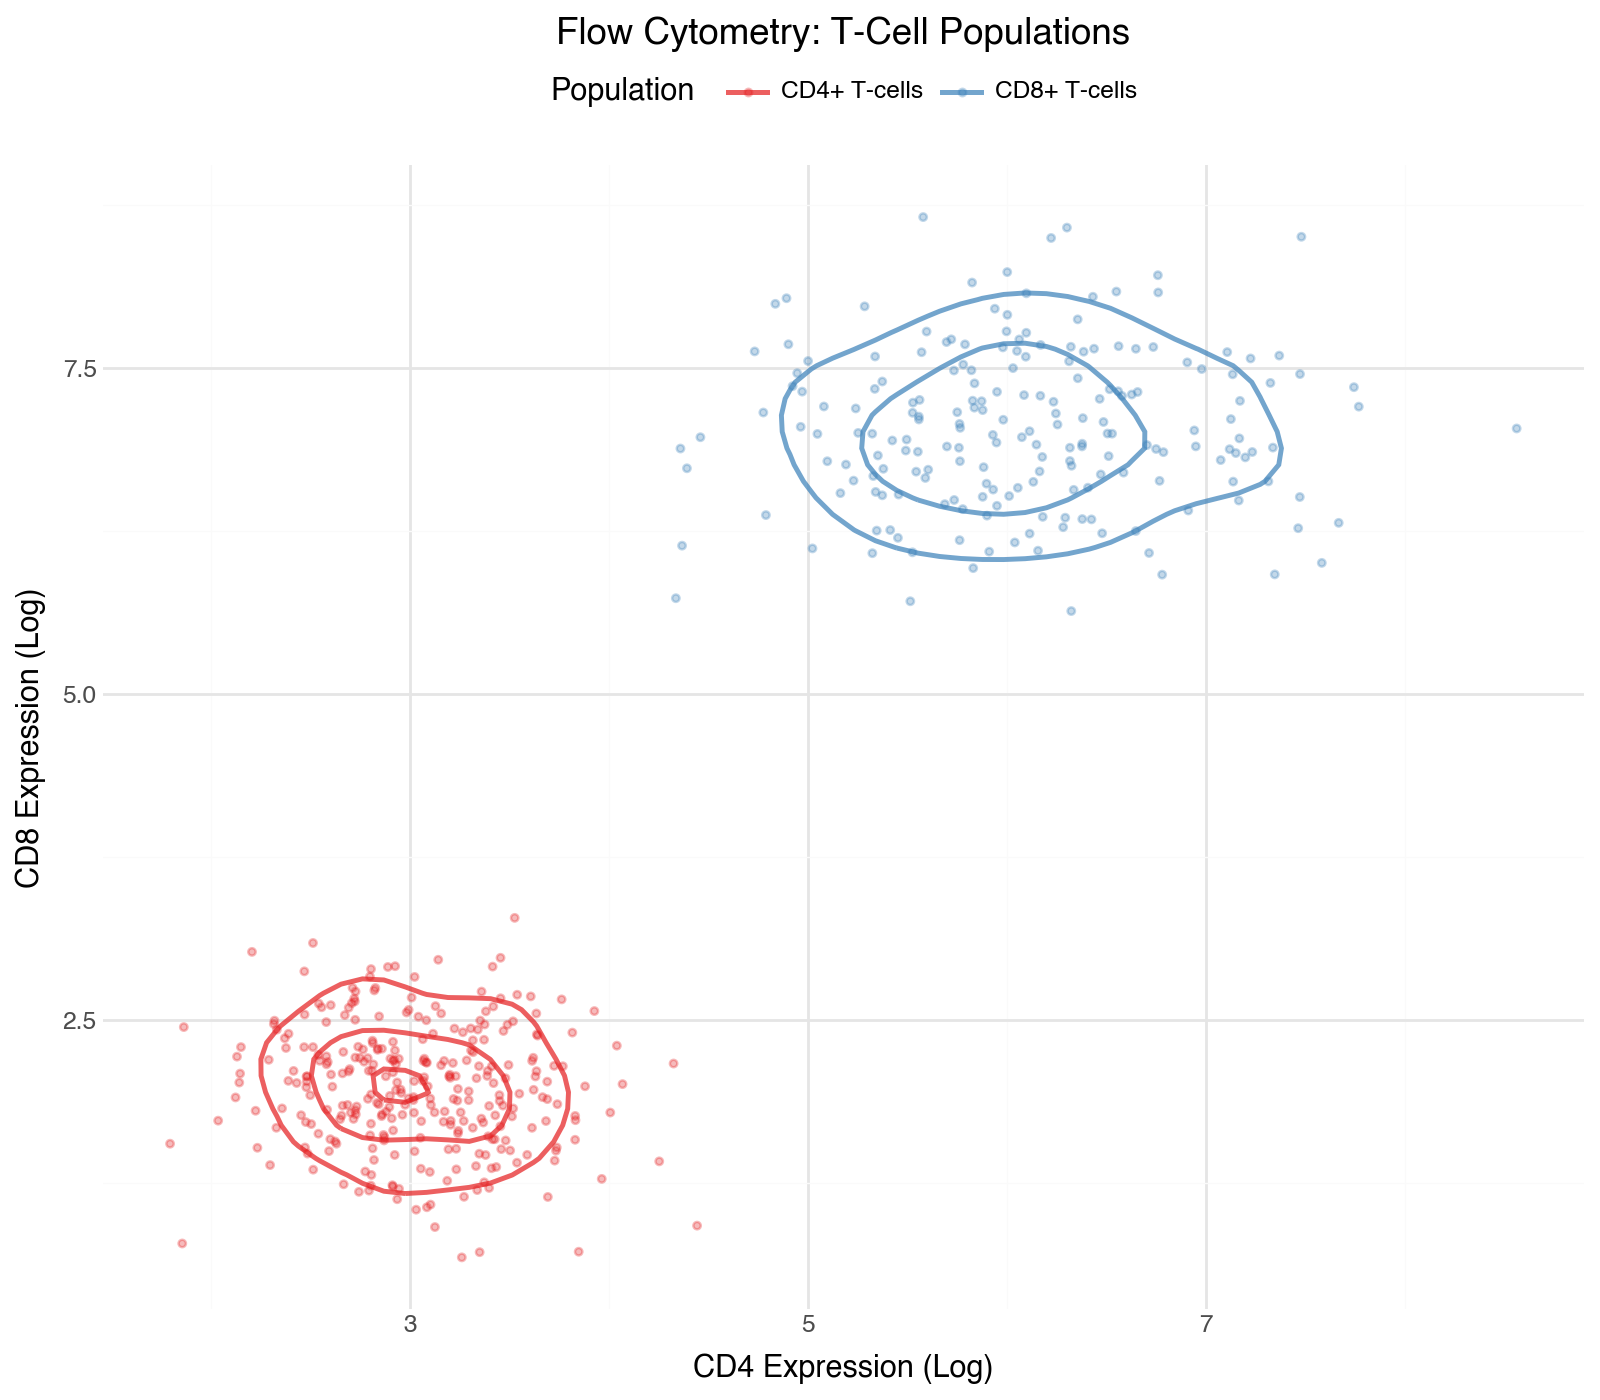

In [15]:
print("\n6. 2D Density Contour (Flow Cytometry Style)")

# Simulate FACS data
facs_df = pd.DataFrame({
    'CD4': np.concatenate([
        np.random.normal(3, 0.5, 300),
        np.random.normal(6, 0.7, 200)
    ]),
    'CD8': np.concatenate([
        np.random.normal(2, 0.5, 300),
        np.random.normal(7, 0.6, 200)
    ]),
    'Population': ['CD4+ T-cells']*300 + ['CD8+ T-cells']*200
})

contour_plot = (
    ggplot(facs_df, aes(x='CD4', y='CD8', color='Population'))
    + geom_point(alpha=0.3, size=1)
    + geom_density_2d(alpha=0.7, size=1)
    + scale_color_brewer(type='qual', palette='Set1')
    + labs(title='Flow Cytometry: T-Cell Populations',
           x='CD4 Expression (Log)',
           y='CD8 Expression (Log)')
    + theme_minimal()
    + theme(figure_size=(8, 7),
            legend_position='top')
)
display(contour_plot)


7. Dumbbell Plot (Paired Comparison)


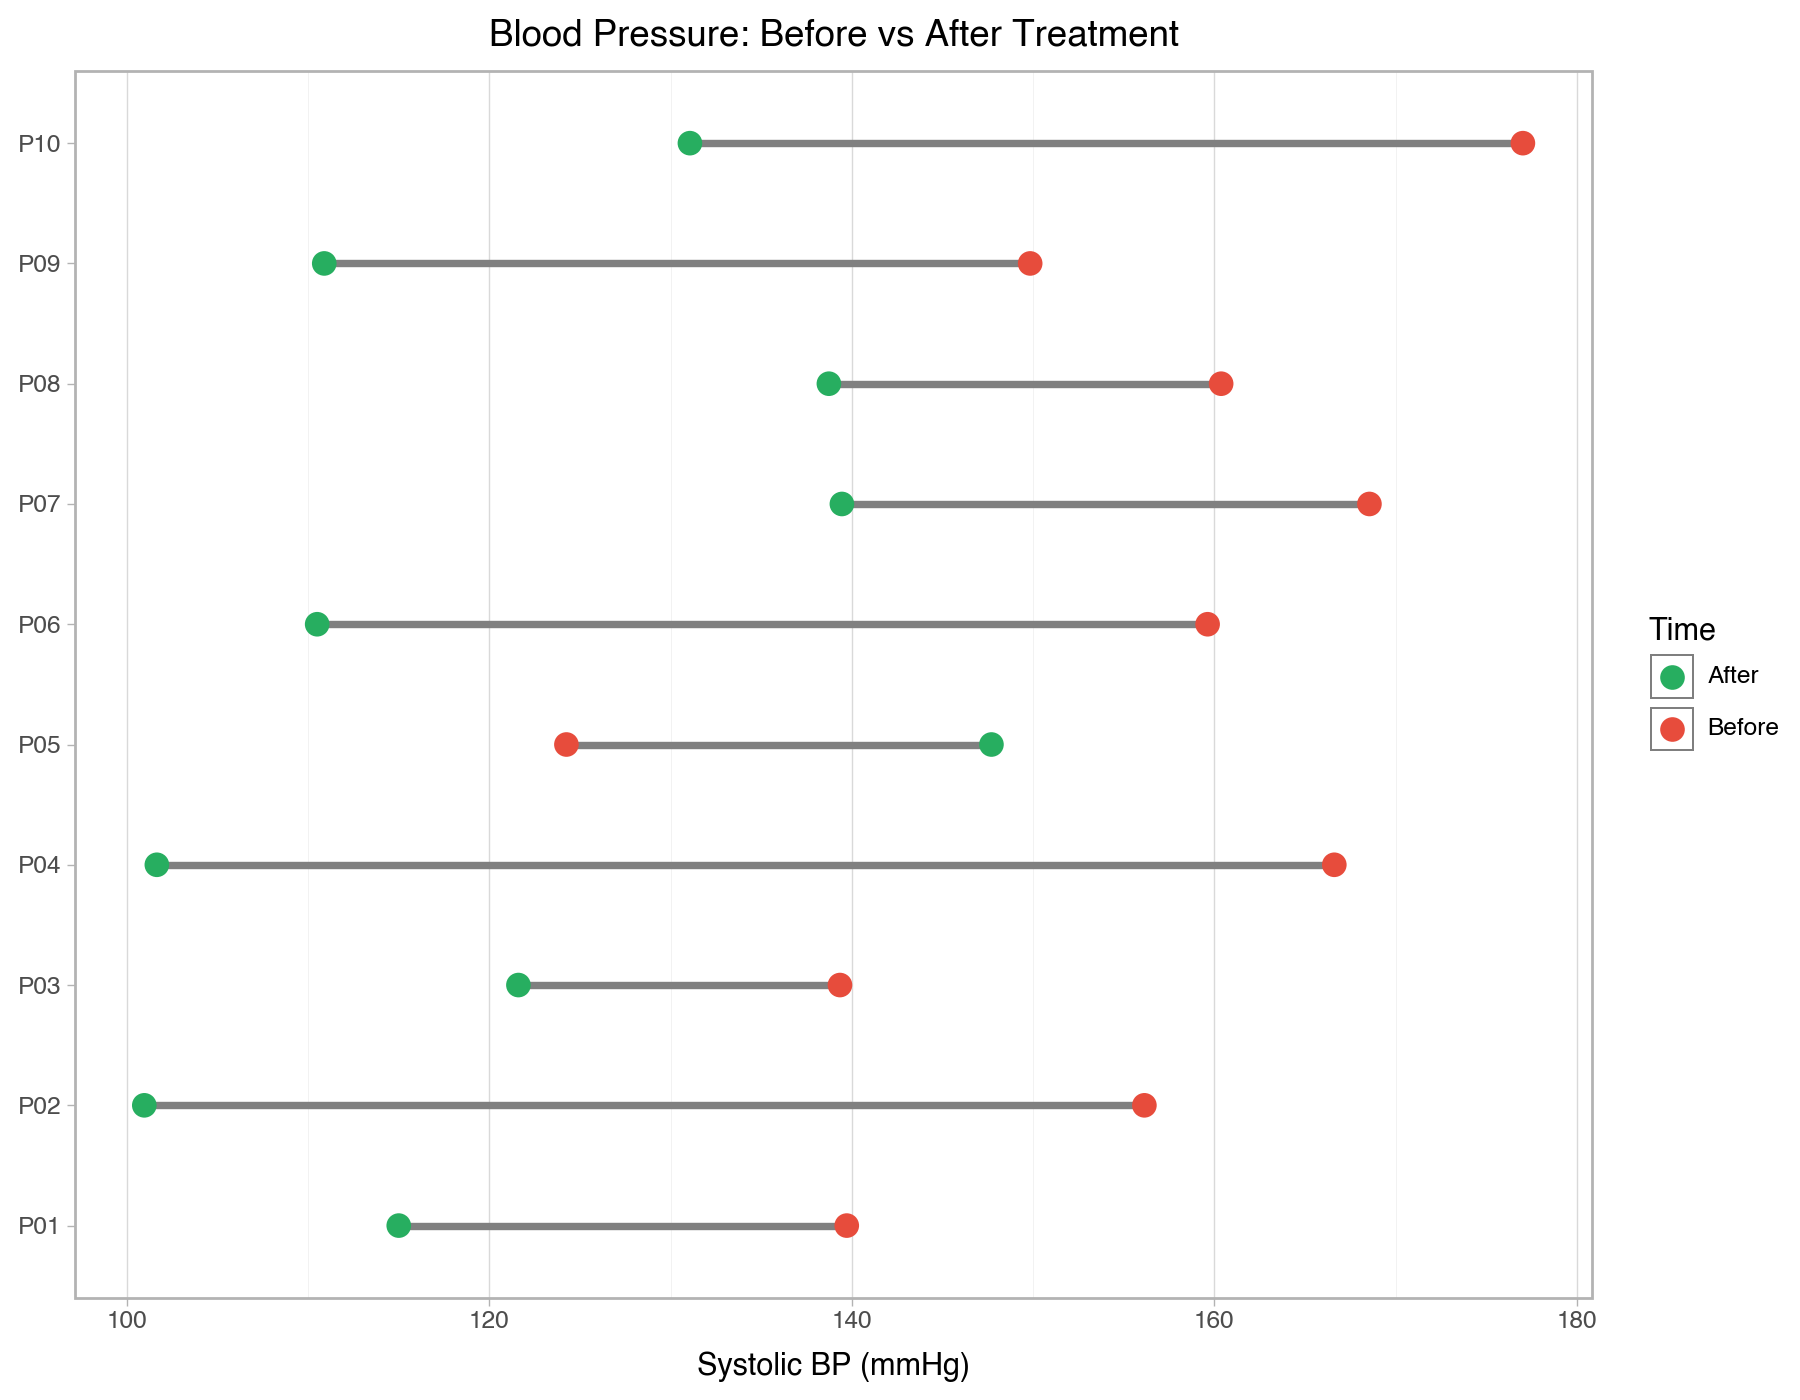

In [16]:
print("\n7. Dumbbell Plot (Paired Comparison)")

before_after = pd.DataFrame({
    'Patient': [f'P{i:02d}' for i in range(1, 11)],
    'Before': np.random.uniform(120, 180, 10),
    'After': np.random.uniform(100, 150, 10)
})
before_after['Change'] = before_after['After'] - before_after['Before']
before_after['Direction'] = before_after['Change'].apply(lambda x: 'Improved' if x < 0 else 'Worsened')

ba_long = pd.melt(before_after, id_vars=['Patient', 'Direction'], 
                  value_vars=['Before', 'After'],
                  var_name='Time', value_name='BloodPressure')

dumbbell = (
    ggplot(ba_long, aes(x='BloodPressure', y='Patient'))
    + geom_line(aes(group='Patient'), color='gray', size=1.5)
    + geom_point(aes(color='Time'), size=4)
    + scale_color_manual(values={'Before': '#e74c3c', 'After': '#27ae60'})
    + labs(title='Blood Pressure: Before vs After Treatment',
           x='Systolic BP (mmHg)',
           y='')
    + theme_light()
    + theme(figure_size=(9, 7),
            panel_grid_major_y=element_blank())
)
display(dumbbell)


8. Raincloud Plot (Distribution + Points + Boxplot)


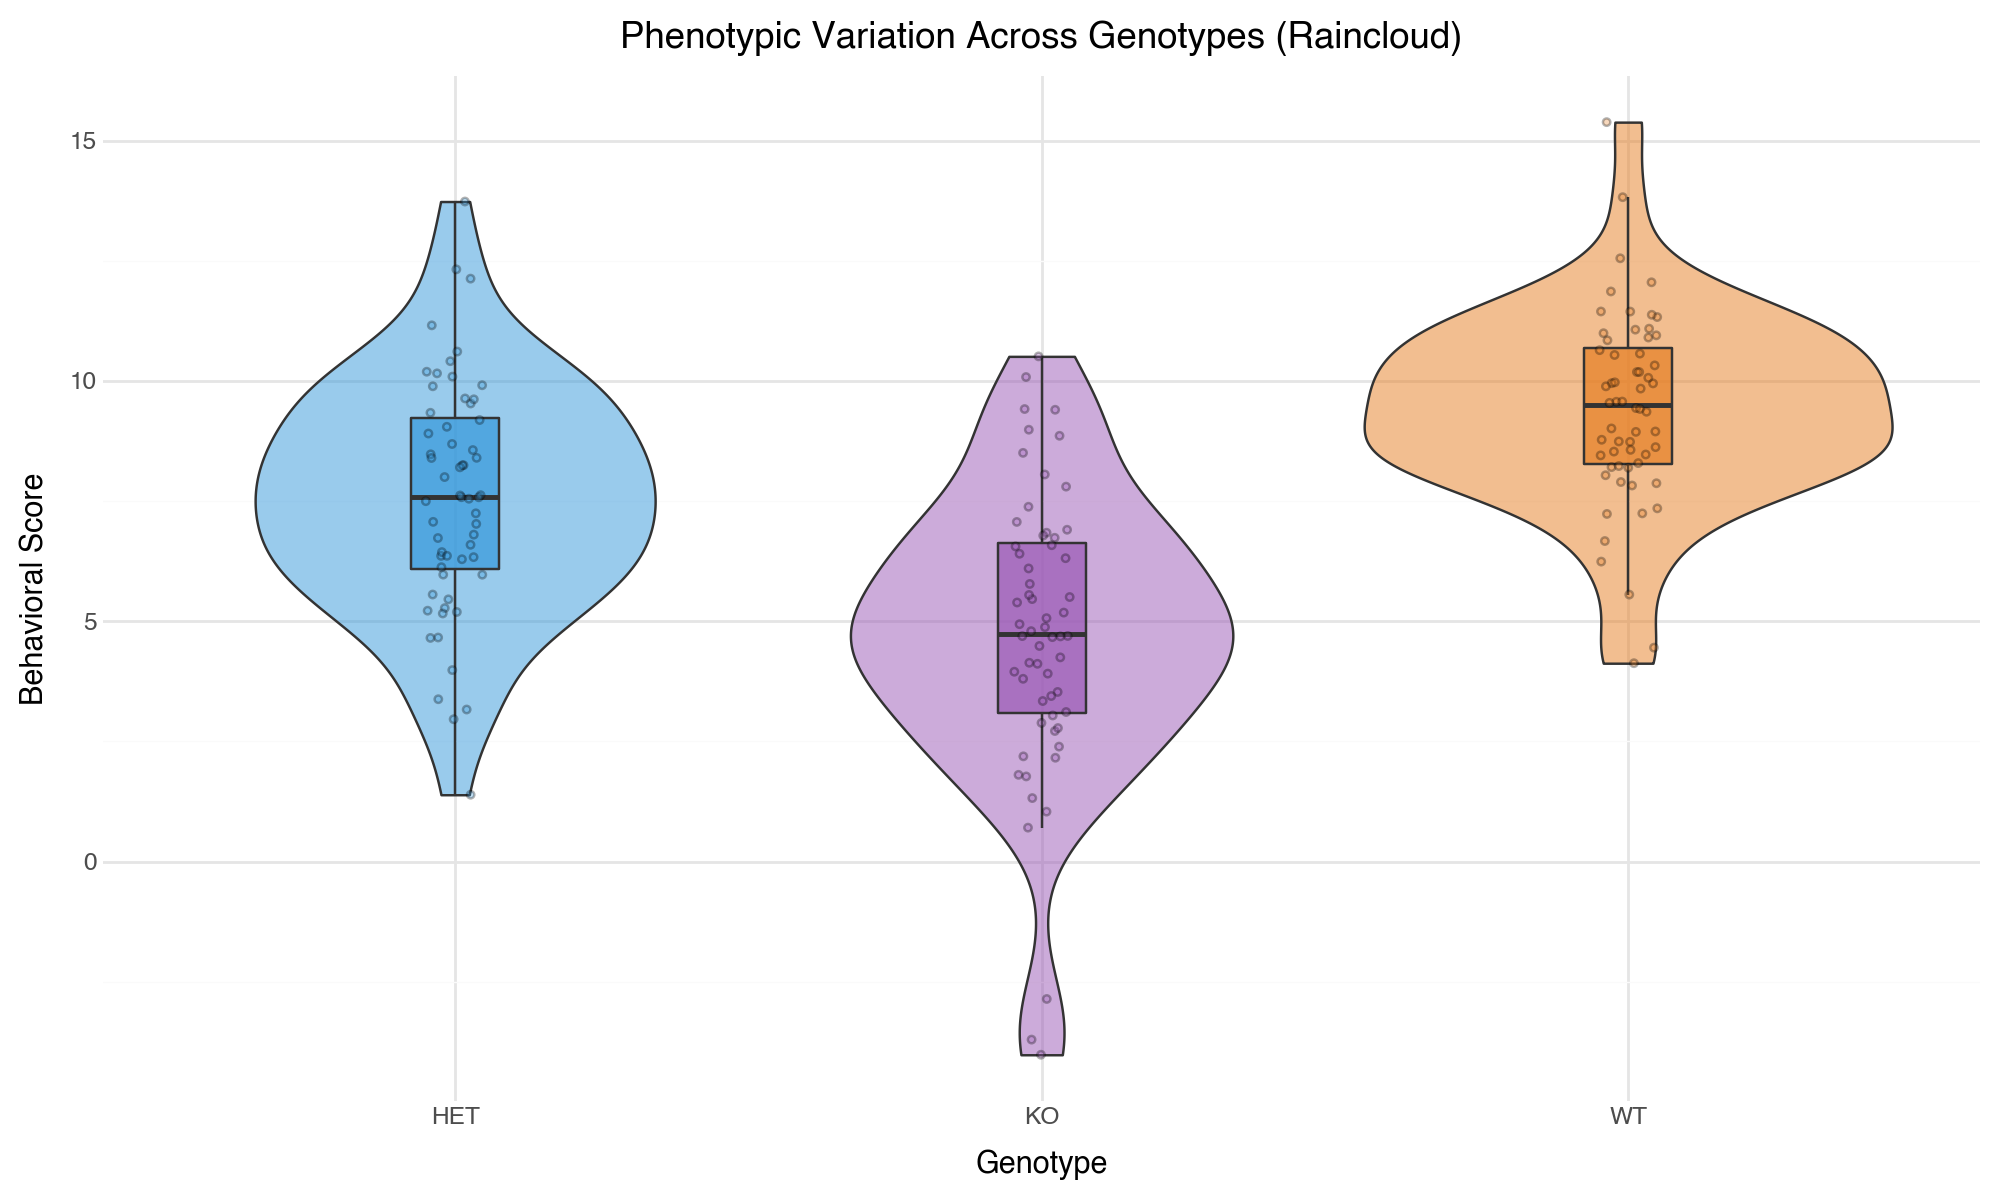

In [17]:
print("\n8. Raincloud Plot (Distribution + Points + Boxplot)")

raincloud_df = pd.DataFrame({
    'Genotype': np.repeat(['WT', 'HET', 'KO'], 60),
    'Phenotype': np.concatenate([
        np.random.normal(10, 2, 60),
        np.random.normal(8, 2.5, 60),
        np.random.normal(5, 3, 60)
    ])
})

raincloud = (
    ggplot(raincloud_df, aes(x='Genotype', y='Phenotype', fill='Genotype'))
    + geom_violin(alpha=0.5, position=position_nudge(x=0.0))
    + geom_boxplot(width=0.15, alpha=0.7, outlier_alpha=0)
    + geom_jitter(width=0.05, alpha=0.3, size=1)
    + scale_fill_manual(values=['#3498db', '#9b59b6', '#e67e22'])
    + labs(title='Phenotypic Variation Across Genotypes (Raincloud)',
           y='Behavioral Score')
    + theme_minimal()
    + theme(figure_size=(10, 6),
            legend_position='none')
)
display(raincloud)

# Plotly

In [18]:
fig = px.scatter(df, x='Gene_X_Log2FC', y='Gene_Y_Log2FC', 
                 color='Group', 
                 hover_data=['Sample_ID', 'Age'],
                 title='Interactive Scatter (Hover to see Sample ID)',
                 template='plotly_white')
fig.show()

# Altair

In [19]:
brush = alt.selection_interval()

points = alt.Chart(df).mark_circle().encode(
    x='Gene_X_Log2FC',
    y='Gene_Y_Log2FC',
    color=alt.condition(brush, 'Group', alt.value('lightgray'))
).add_params(brush).properties(width=300)

bars = alt.Chart(df).mark_bar().encode(
    y='Group',
    color='Group',
    x='count()'
).transform_filter(brush).properties(width=300)

display(points | bars)

alt.HConcatChart(...)

In [20]:
print("1. Multi-Panel Linked Brushing Dashboard")

n = 300
dashboard_df = pd.DataFrame({
    'Patient_ID': [f'P{i:03d}' for i in range(n)],
    'Age': np.random.randint(25, 80, n),
    'BMI': np.random.normal(27, 5, n),
    'Glucose': np.random.normal(100, 25, n),
    'Cholesterol': np.random.normal(200, 40, n),
    'BloodPressure': np.random.normal(120, 20, n),
    'RiskGroup': np.random.choice(['Low', 'Medium', 'High'], n, p=[0.5, 0.3, 0.2])
})

# Create interval selection
brush = alt.selection_interval(encodings=['x', 'y'])

# Scatter plot 1: Age vs BMI
scatter1 = alt.Chart(dashboard_df).mark_circle(size=60).encode(
    x=alt.X('Age:Q', scale=alt.Scale(zero=False)),
    y=alt.Y('BMI:Q', scale=alt.Scale(zero=False)),
    color=alt.condition(brush, 'RiskGroup:N', alt.value('lightgray')),
    tooltip=['Patient_ID', 'Age', 'BMI', 'RiskGroup']
).add_params(brush).properties(
    width=250,
    height=250,
    title='Age vs BMI'
)

# Scatter plot 2: Glucose vs Cholesterol
scatter2 = alt.Chart(dashboard_df).mark_circle(size=60).encode(
    x=alt.X('Glucose:Q', scale=alt.Scale(zero=False)),
    y=alt.Y('Cholesterol:Q', scale=alt.Scale(zero=False)),
    color=alt.condition(brush, 'RiskGroup:N', alt.value('lightgray')),
    tooltip=['Patient_ID', 'Glucose', 'Cholesterol', 'RiskGroup']
).add_params(brush).properties(
    width=250,
    height=250,
    title='Glucose vs Cholesterol'
)

# Histogram filtered by selection
hist = alt.Chart(dashboard_df).mark_bar().encode(
    x=alt.X('BloodPressure:Q', bin=alt.Bin(maxbins=30)),
    y='count()',
    color='RiskGroup:N'
).transform_filter(brush).properties(
    width=520,
    height=150,
    title='Blood Pressure Distribution (Filtered)'
)

dashboard = alt.vconcat(
    alt.hconcat(scatter1, scatter2),
    hist
).properties(
    title='Interactive Clinical Dashboard - Brush to Filter'
).configure_title(fontSize=16, anchor='middle')

display(dashboard)

1. Multi-Panel Linked Brushing Dashboard


alt.VConcatChart(...)

In [21]:
print("\n2. Interactive Gene Expression Heatmap")

genes = [f'Gene_{i}' for i in range(20)]
samples = [f'Sample_{i}' for i in range(15)]
heatmap_df = pd.DataFrame([
    {'Gene': g, 'Sample': s, 'Expression': np.random.exponential(2) + np.random.normal(0, 0.5)}
    for g in genes for s in samples
])

heatmap = alt.Chart(heatmap_df).mark_rect().encode(
    x=alt.X('Sample:N', axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('Gene:N'),
    color=alt.Color('Expression:Q', 
                    scale=alt.Scale(scheme='redyellowblue', reverse=True),
                    legend=alt.Legend(title='Log2 Expression')),
    tooltip=[
        alt.Tooltip('Gene:N'),
        alt.Tooltip('Sample:N'),
        alt.Tooltip('Expression:Q', format='.2f')
    ]
).properties(
    width=600,
    height=400,
    title='Gene Expression Heatmap'
).configure_axis(
    labelFontSize=10
)

display(heatmap)


2. Interactive Gene Expression Heatmap


alt.Chart(...)

In [22]:
print("\n3. Curves with Selector")

treatments = ['Placebo', 'Drug_A', 'Drug_B', 'Drug_C']
survival_data = []
for treatment in treatments:
    times = np.arange(0, 25, 0.5)
    if treatment == 'Placebo':
        survival = np.exp(-0.15 * times) + np.random.normal(0, 0.02, len(times))
    elif treatment == 'Drug_A':
        survival = np.exp(-0.10 * times) + np.random.normal(0, 0.02, len(times))
    elif treatment == 'Drug_B':
        survival = np.exp(-0.08 * times) + np.random.normal(0, 0.02, len(times))
    else:
        survival = np.exp(-0.12 * times) + np.random.normal(0, 0.02, len(times))
    survival = np.clip(survival, 0, 1)
    
    for t, s in zip(times, survival):
        survival_data.append({'Treatment': treatment, 'Time': t, 'Survival': s})

survival_df = pd.DataFrame(survival_data)

# Dropdown selector
treatment_dropdown = alt.binding_select(options=[None] + treatments, name='Treatment: ')
treatment_select = alt.selection_point(fields=['Treatment'], bind=treatment_dropdown, value='Drug_A')

survival_plot = alt.Chart(survival_df).mark_line(size=3, point=True).encode(
    x=alt.X('Time:Q', title='Time (months)'),
    y=alt.Y('Survival:Q', title='Probability', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Treatment:N', legend=alt.Legend(title='Treatment Group')),
    opacity=alt.condition(treatment_select, alt.value(1), alt.value(0.2)),
    tooltip=['Treatment', 'Time', alt.Tooltip('Survival:Q', format='.3f')]
).add_params(treatment_select).properties(
    width=700,
    height=400,
    title='Curves Selection'
)

display(survival_plot)


3. Curves with Selector


alt.Chart(...)

# UpSetPlot

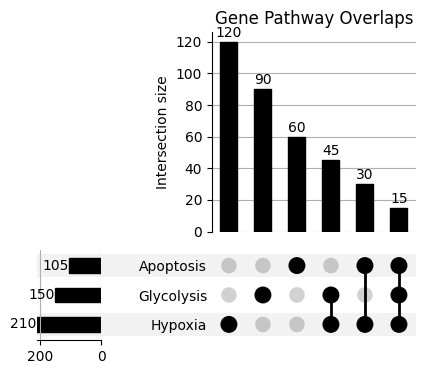

In [23]:
from upsetplot import plot as upset_plot
from upsetplot import from_memberships

# Data: Pathways affected
example_sets = from_memberships(
    [
        ['Hypoxia'],
        ['Glycolysis'],
        ['Hypoxia', 'Glycolysis'], # Intersection
        ['Hypoxia', 'Apoptosis'],
        ['Hypoxia', 'Glycolysis', 'Apoptosis'], # Triple intersection
        ['Apoptosis'],
    ],
    data=[120, 90, 45, 30, 15, 60] # Count of genes
)

upset_plot(example_sets, show_counts=True)
plt.title("Gene Pathway Overlaps")
plt.show()

# YellowBrick

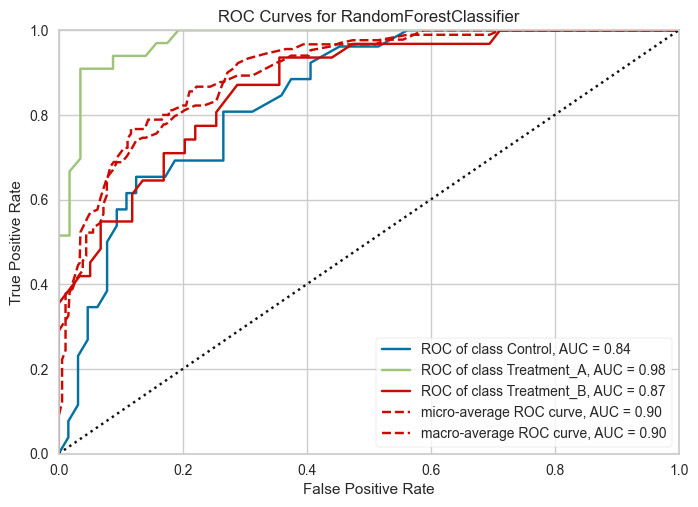

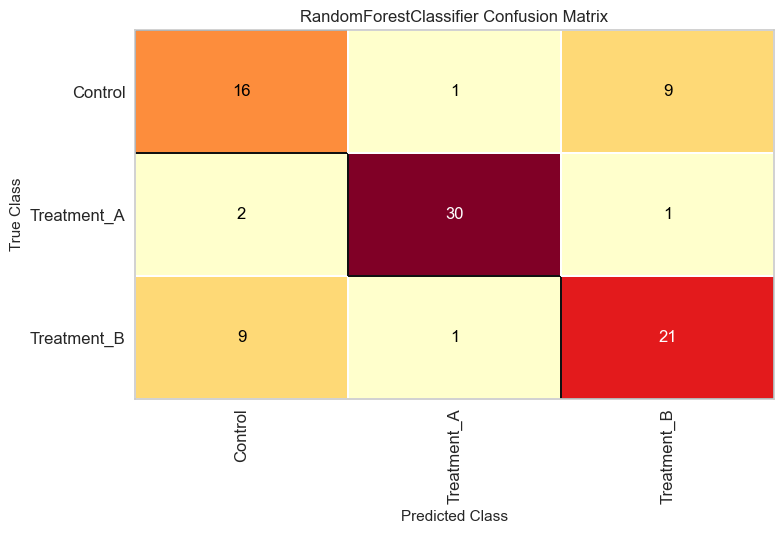

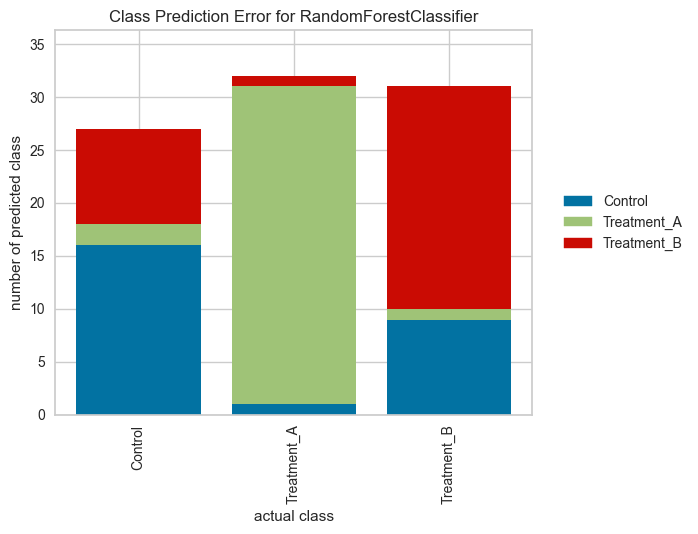

<Axes: title={'center': 'Class Prediction Error for RandomForestClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from yellowbrick.classifier import ROCAUC, ConfusionMatrix, ClassPredictionError

# Prep data
X = df[['Age', 'Gene_X_Log2FC', 'Gene_Y_Log2FC', 'Pathway_Activity']]
y = df['Group']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = RandomForestClassifier()

# Visualize 1: ROC AUC Curve
visualizer = ROCAUC(model, classes=['Control', 'Treatment_A', 'Treatment_B'])
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

# Visualize 2: Confusion Matrix
visualizer = ConfusionMatrix(model, classes=['Control', 'Treatment_A', 'Treatment_B'])
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

# Visualize 3: Class Prediction Error
visualizer = ClassPredictionError(model, classes=['Control', 'Treatment_A', 'Treatment_B'])
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

# statannotations

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. Treatment_A: t-test independent samples, P_val:9.832e-45 t=-1.860e+01
Treatment_B vs. Control: t-test independent samples, P_val:6.035e-01 t=5.201e-01


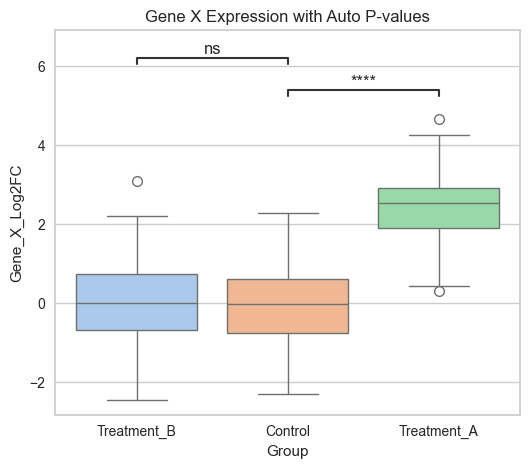

In [25]:
from statannotations.Annotator import Annotator

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='Group', y='Gene_X_Log2FC', ax=ax, palette='pastel')

# Define comparisons
pairs = [("Control", "Treatment_A"), ("Control", "Treatment_B")]

annotator = Annotator(ax, pairs, data=df, x='Group', y='Gene_X_Log2FC')
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.title("Gene X Expression with Auto P-values")
plt.show()

# YData Profiling

In [26]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Clinical Data Audit", minimal=True)
profile.to_file("clinical_audit.html")
print("ProfileReport object created. Run profile.to_file() to export HTML.")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 32263.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

ProfileReport object created. Run profile.to_file() to export HTML.


# Datashader

Simulating High-Throughput Data...
Rendered 2M points:


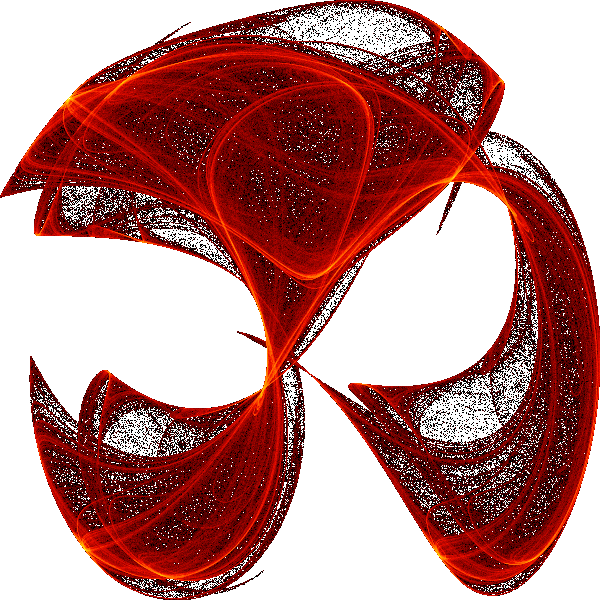

In [31]:
# Generate a synthetic dataset (Clifford Attractor)
def clifford_attractor(n, a=-1.4, b=1.6, c=1.0, d=0.75):
    x, y = np.zeros(n), np.zeros(n)
    for i in range(n-1):
        x[i+1] = np.sin(a*y[i]) + c*np.cos(a*x[i])
        y[i+1] = np.sin(b*x[i]) + d*np.cos(b*y[i])
    return pd.DataFrame({'x': x, 'y': y})

print("Simulating High-Throughput Data...")
df_big = clifford_attractor(2000000)

cvs = ds.Canvas(plot_width=600, plot_height=600)
agg = cvs.points(df_big, 'x', 'y')
img = tf.shade(agg, cmap=cc.fire, how='log')

print("Rendered 2M points:")
display(img)

# Ipywidgets

In [28]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
print("\n1. Interactive Gene Expression Filter")

# Create sample data
np.random.seed(42)
n_genes = 100
gene_data = pd.DataFrame({
    'Gene': [f'Gene_{i:03d}' for i in range(n_genes)],
    'Log2FC': np.random.normal(0, 2, n_genes),
    'PValue': np.random.beta(0.5, 2, n_genes),
    'Expression': np.random.exponential(5, n_genes)
})
gene_data['NegLog10P'] = -np.log10(gene_data['PValue'] + 1e-10)

# Create interactive plot function
def plot_volcano(fc_threshold=1.0, p_threshold=0.05):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Calculate significance
    significant = (np.abs(gene_data['Log2FC']) > fc_threshold) & \
                  (gene_data['PValue'] < p_threshold)
    
    # Plot
    ax.scatter(gene_data.loc[~significant, 'Log2FC'], 
               gene_data.loc[~significant, 'NegLog10P'],
               c='gray', alpha=0.5, s=30, label='NS')
    ax.scatter(gene_data.loc[significant, 'Log2FC'], 
               gene_data.loc[significant, 'NegLog10P'],
               c='red', alpha=0.7, s=50, label='Significant')
    
    # Threshold lines
    ax.axhline(-np.log10(p_threshold), linestyle='--', color='blue', alpha=0.5)
    ax.axvline(-fc_threshold, linestyle='--', color='blue', alpha=0.5)
    ax.axvline(fc_threshold, linestyle='--', color='blue', alpha=0.5)
    
    ax.set_xlabel('Log₂ Fold Change')
    ax.set_ylabel('-Log₁₀ P-Value')
    ax.set_title(f'Volcano Plot ({significant.sum()} significant genes)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create widgets
fc_slider = widgets.FloatSlider(
    value=1.0,
    min=0.5,
    max=3.0,
    step=0.1,
    description='FC Cutoff:',
    continuous_update=False
)

p_slider = widgets.FloatLogSlider(
    value=0.05,
    base=10,
    min=-4,
    max=-1,
    step=0.1,
    description='P-Value:',
    continuous_update=False
)

widgets.interact(plot_volcano, fc_threshold=fc_slider, p_threshold=p_slider)


1. Interactive Gene Expression Filter


interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='FC Cutoff:', max=3.0, min=0…

<function __main__.plot_volcano(fc_threshold=1.0, p_threshold=0.05)>

In [ ]:
print("\n2. Treatment Response Timeline Explorer")

# Generate time course data
timepoints = np.arange(0, 48, 0.5)
treatments = ['Control', 'Drug_A', 'Drug_B', 'Drug_C']

def generate_response(treatment, noise_level):
    if treatment == 'Control':
        response = 100 + np.random.normal(0, noise_level, len(timepoints))
    elif treatment == 'Drug_A':
        response = 100 - 30 * (1 - np.exp(-timepoints/10)) + \
                   np.random.normal(0, noise_level, len(timepoints))
    elif treatment == 'Drug_B':
        response = 100 - 50 * (1 - np.exp(-timepoints/15)) + \
                   np.random.normal(0, noise_level, len(timepoints))
    else:
        response = 100 - 20 * (1 - np.exp(-timepoints/8)) + \
                   np.random.normal(0, noise_level, len(timepoints))
    return response

def plot_timeline(selected_treatments, noise_level, show_ci):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = {'Control': 'gray', 'Drug_A': 'crimson', 
              'Drug_B': 'dodgerblue', 'Drug_C': 'green'}
    
    for treatment in selected_treatments:
        # Generate multiple replicates
        replicates = np.array([generate_response(treatment, noise_level) 
                               for _ in range(5)])
        mean_response = replicates.mean(axis=0)
        std_response = replicates.std(axis=0)
        
        ax.plot(timepoints, mean_response, label=treatment, 
                color=colors[treatment], linewidth=2)
        
        if show_ci:
            ax.fill_between(timepoints, 
                           mean_response - std_response,
                           mean_response + std_response,
                           color=colors[treatment], alpha=0.2)
    
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Response (%)')
    ax.set_title('Treatment Response Over Time')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create widgets
treatment_select = widgets.SelectMultiple(
    options=treatments,
    value=['Control', 'Drug_A'],
    description='Treatments:',
    disabled=False
)

noise_slider = widgets.FloatSlider(
    value=5.0,
    min=1.0,
    max=15.0,
    step=1.0,
    description='Noise:',
    continuous_update=False
)

ci_checkbox = widgets.Checkbox(
    value=True,
    description='Show Confidence Interval',
    disabled=False
)

widgets.interact(plot_timeline, 
                selected_treatments=treatment_select,
                noise_level=noise_slider,
                show_ci=ci_checkbox)


2. Treatment Response Timeline Explorer


interactive(children=(SelectMultiple(description='Treatments:', index=(0, 1), options=('Control', 'Drug_A', 'D…

<function __main__.plot_timeline(selected_treatments, noise_level, show_ci)>